# Random Forest

## Mushroom Dataset

#### Final Project: DSC 345/445

#### Victoria Burke and Rebecca Henzig

Random Forest is an ensemble learning method that builds a large number of decision trees during training, and outputs the class predictions. By averaging across many trees trained on random subsets of the data and features, RF reduces the variance associated with single decision trees.



## Data Preparation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


df = pd.read_csv('../data/cleaned_mushrooms.csv')

# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 123, stratify = y
)

# One-hot encoding
cat_cols = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## Baseline Model

Before tuning, we trained a baseline Random Forest with 100 trees, giving a reference point to measure whether hyperparameter tuning actually improved results.

In [31]:
# Baseline Random Forest

rf_baseline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 100, random_state=123))
])
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## n_estimators 

The number of decision trees in the ensemble is one of the most important hyperparameters. More trees usually improves stability, but with diminishing returns. Values from 10 to 500 are tested to find where accuracy plateaus, telling us the minimum number of trees needed.

Train Scores:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Test Scores:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


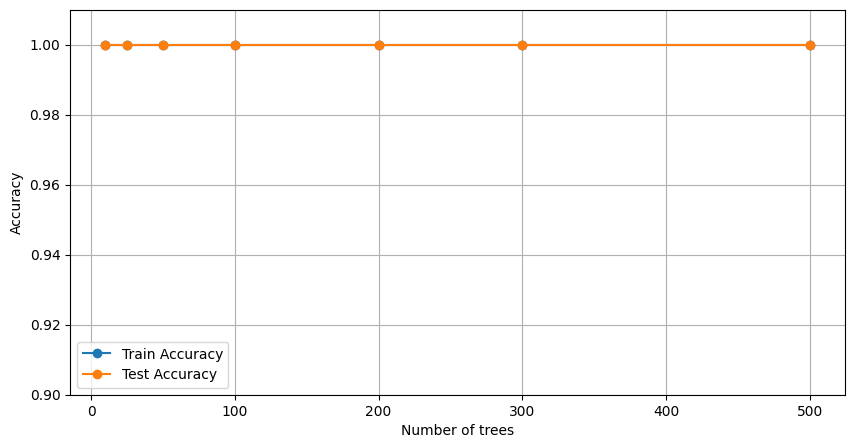

In [ ]:
# n estimators 

estimators = [10, 25, 50, 100, 200, 300, 500]
train_scores = []
test_scores = []

for n in estimators:
    rf = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators = n, random_state=123))
    ])
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

print("Train Scores: ", train_scores)
print("Test Scores: ", test_scores)

plt.figure(figsize=(10, 5))
plt.plot(estimators, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimators, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Number of trees')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(True)
#plt.savefig('../results/rf_estimators.png')
plt.show()

## Hyperparameter Tuning

We used Grid Search with 5 fold cross validation to search over n_estimators, max_depth, max_features, and min_samples_split. We also decided to evaluate the F1 score rather than accuracy to account for the slight class imbalance.

In [33]:
# Grid search for n_estimators

from sklearn.model_selection import GridSearchCV


rf_grid = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=123))
])

param_grid = {
    'classifier__n_estimators': [100,200,300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator = rf_grid,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1_weighted',
    verbose = 1
)

grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)
print("Test accuracy: ", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters:  {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best score:  1.0
Test accuracy:  1.0


              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



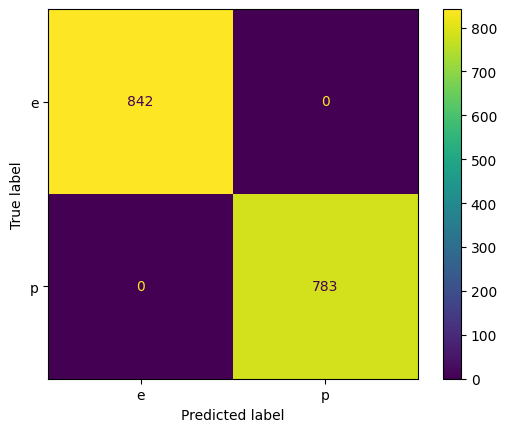

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_best))
ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)
#plt.savefig('../results/rf_confusion_matrix.png')
plt.show()

## Feature Importance

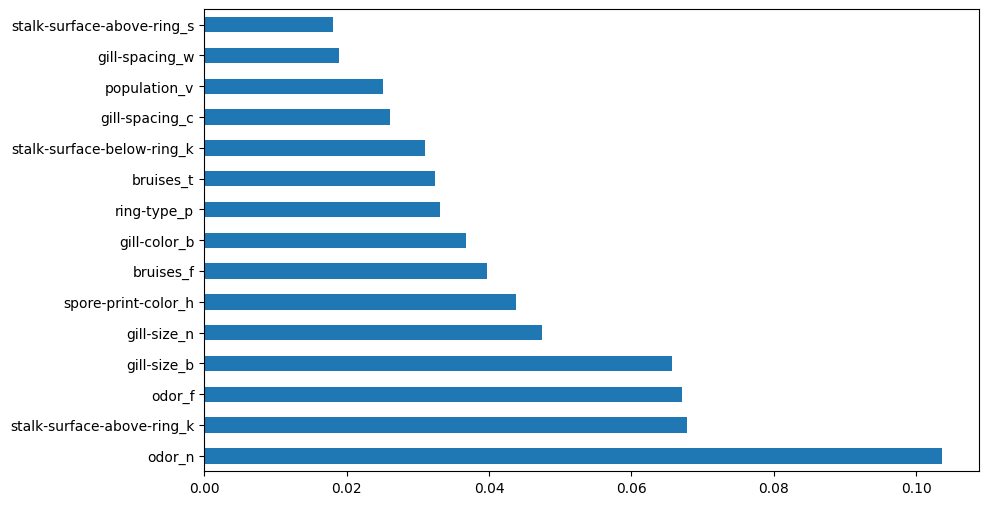

In [35]:
# feature importance

best_rf = grid_search.best_estimator_.named_steps['classifier']
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()

importances = pd.Series(best_rf.feature_importances_, index = feature_names)
top_features = importances.sort_values(ascending = False).head(15)
plt.figure(figsize=(10,6))

top_features.plot(kind = 'barh')
plt.show()

As reported from the exploratory data analysis, odor dominates the feature importance ranking. The top features identified by the model closely follow what was reported in the Chi-squared rankings, providing validation of which attributes carry the most weight.

## Results

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(grid_search.best_estimator_, X, y, cv=5, scoring='accuracy')


results = pd.DataFrame([{
    'model': 'Random Forest',
    'best_n_estimators': grid_search.best_params_['classifier__n_estimators'],
    'best_max_depth': grid_search.best_params_['classifier__max_depth'],
    'best_max_features': grid_search.best_params_['classifier__max_features'],
    'cv_f1': grid_search.best_score_,
    'cv_accuracy_mean': cv_scores.mean(),
    'cv_accuracy_std': cv_scores.std(),
    'test_accuracy': accuracy_score(y_test, y_pred_best),
    'test_f1': classification_report(y_test, y_pred_best, output_dict=True )['weighted avg']['f1-score'],
}])
print(results)



           model  best_n_estimators best_max_depth best_max_features  cv_f1  \
0  Random Forest                100           None              sqrt    1.0   

   cv_accuracy_mean  cv_accuracy_std  test_accuracy  test_f1  
0          0.924281         0.094315            1.0      1.0  


The model was able to achieve perfect accuracy and F1 score, which is great for a problem like this where the ramifications of eating a poisonous mushroom could be very bad. The model with 100 n_estimators proved to be the best, and there was a CV accuracy standard deviation of 0.094, which is interesting and unexpected. This could be due to one fold encountering a distribution issue which could be worth investigating later.